In [ ]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-ezd9b0r3
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-ezd9b0r3
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-v2iti7eh/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter


In [ ]:
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp1w1r36an".


In [ ]:
%%cuda
#include <stdio.h>

__global__ void helloCUDA() {
    printf("Hello from GPU thread %d\n", threadIdx.x);
}

int main() {
    helloCUDA<<<1, 5>>>();
    cudaDeviceSynchronize();
    return 0;
}

Hello from GPU thread 0
Hello from GPU thread 1
Hello from GPU thread 2
Hello from GPU thread 3
Hello from GPU thread 4



LAB 3

In [ ]:
%%cuda
#include <stdio.h>

#define N 10 // Represents the size of the vectors

// Declares a CUDA kernel function vectorAdd. It uses the thread index (threadIdx.x) to determine the element to be processed.
__global__ void vectorAdd(int *a, int *b, int *c) {
    int tid = threadIdx.x;
    if (tid < N) {
        c[tid] = a[tid] + b[tid];
    }
}

int main() {
    // Host arrays a, b and c declare to store vectors and corresponding device (GPU) arrays d_a, d_b and d_c are declared for memory allocation on GPU.
    int a[N], b[N], c[N];
    int *d_a, *d_b, *d_c;

    // Allocate device memory (This allocates memory on the GPU for the vectors).
    cudaMalloc((void**)&d_a, N * sizeof(int));
    cudaMalloc((void**)&d_b, N * sizeof(int));
    cudaMalloc((void**)&d_c, N * sizeof(int));

    // Initialize host vectors (This loop initializes the host vectors a and b with sequential values).
    for (int i = 0; i < N; ++i) {
        a[i] = i;
        b[i] = 2 * i;
    }

    // Copy host vectors to device (These lines copy the host vectors a and b to the corresponding device vectors d_a and d_b).
    cudaMemcpy(d_a, a, N * sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, b, N * sizeof(int), cudaMemcpyHostToDevice);

    // Launch the vectorAdd kernel with N threads (This launches the vectorAdd kernel on the GPU with one block containing N threads).
    vectorAdd<<<1, N>>>(d_a, d_b, d_c);

    // Copy result from device to host (This copies the result vector d_c from the GPU back to the host vector c).
    cudaMemcpy(c, d_c, N * sizeof(int), cudaMemcpyDeviceToHost);

    // Print result
    for (int i = 0; i < N; ++i) {
        printf("%d + %d = %d\n", a[i], b[i], c[i]);
    }

    // Free device memory (This frees the memory allocated on the GPU).
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    return 0;
}

0 + 0 = 0
1 + 2 = 3
2 + 4 = 6
3 + 6 = 9
4 + 8 = 12
5 + 10 = 15
6 + 12 = 18
7 + 14 = 21
8 + 16 = 24
9 + 18 = 27



LAB 4

In [ ]:
%%cuda
#include <stdio.h>

#define N 3 // Represents the size of the square matrices (N x N)

// Declares a CUDA kernel function matrixMul. It uses the thread indices to determine the specific element of the resulting matrix to be calculated.
__global__ void matrixMul(int *a, int *b, int *c) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        int sum = 0;
        for (int k = 0; k < N; ++k) {
            sum += a[row * N + k] * b[k * N + col];
        }
        c[row * N + col] = sum;
    }
}

int main() {
    // Host arrays a, b, and c are declared to store the matrices.
    int a[N * N], b[N * N], c[N * N];
    // Corresponding device (GPU) arrays d_a, d_b, and d_c are declared for memory allocation on the GPU.
    int *d_a, *d_b, *d_c;

    // Allocate memory on the GPU for the matrices d_a, d_b, and d_c.
    cudaMalloc((void**)&d_a, N * N * sizeof(int));
    cudaMalloc((void**)&d_b, N * N * sizeof(int));
    cudaMalloc((void**)&d_c, N * N * sizeof(int));

    // Initialize host matrices a and b with sequential values.
    for (int i = 0; i < N * N; ++i) {
        a[i] = i;
        b[i] = 2 * i;
    }

    // Copy the host matrices a and b to the corresponding device matrices d_a and d_b.
    cudaMemcpy(d_a, a, N * N * sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, b, N * N * sizeof(int), cudaMemcpyHostToDevice);

    // Set up grid and block dimensions for the CUDA kernel.
    // A 1x1 grid is used, and each block is an N x N block (matching the matrix size).
    dim3 gridDim(1, 1, 1);
    dim3 blockDim(N, N, 1);

    // Launch the matrixMul kernel with the defined grid and block dimensions.
    matrixMul<<<gridDim, blockDim>>>(d_a, d_b, d_c);

    // Copy the result matrix d_c from the GPU back to the host matrix c.
    cudaMemcpy(c, d_c, N * N * sizeof(int), cudaMemcpyDeviceToHost);

    // Print input matrices and the result matrix
    printf("Matrix A:\n");
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            printf("%4d ", a[i * N + j]);
        }
        printf("\n");
    }

    printf("\nMatrix B:\n");
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            printf("%4d ", b[i * N + j]);
        }
        printf("\n");
    }

    printf("\nResult Matrix C (A * B):\n");
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            printf("%4d ", c[i * N + j]);
        }
        printf("\n");
    }

    // Free the memory allocated on the GPU.
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    return 0;
}

Matrix A:
   0    1    2 
   3    4    5 
   6    7    8 

Matrix B:
   0    2    4 
   6    8   10 
  12   14   16 

Result Matrix C (A * B):
  30   36   42 
  84  108  132 
 138  180  222 



LAB 5

In [ ]:
%%cuda
#include <stdio.h>
#include <cuda.h>

#define N 16

// Kernel to extract bit
__global__ void extractBit(int *input, int *bit, int shift, int n) {
    int i = threadIdx.x + blockIdx.x * blockDim.x;
    if (i < n) {
        bit[i] = (input[i] >> shift) & 1;
    }
}

// Prefix sum (exclusive scan)
__global__ void prefixSum(int *bit, int *scan, int n) {
    int i = threadIdx.x;

    if (i == 0) scan[0] = 0;
    __syncthreads();

    if (i < n && i > 0) {
        scan[i] = bit[i - 1];
    }
    __syncthreads();

    for (int offset = 1; offset < n; offset <<= 1) {
        int temp = 0;
        if (i >= offset) temp = scan[i - offset];
        __syncthreads();
        scan[i] += temp;
        __syncthreads();
    }
}

// Rearrange elements
__global__ void rearrange(int *input, int *output,
                          int *bit, int *scan,
                          int totalZeros, int n) {
    int i = threadIdx.x;

    if (i < n) {
        if (bit[i] == 0) {
            int pos = i - scan[i];
            output[pos] = input[i];
        } else {
            int pos = totalZeros + scan[i];
            output[pos] = input[i];
        }
    }
}

void radixSort(int *d_input, int *d_output, int n) {
    int *d_bit, *d_scan;
    cudaMalloc(&d_bit, n * sizeof(int));
    cudaMalloc(&d_scan, n * sizeof(int));

    for (int shift = 0; shift < 32; shift++) {

        extractBit<<<1, n>>>(d_input, d_bit, shift, n);
        cudaDeviceSynchronize();

        prefixSum<<<1, n>>>(d_bit, d_scan, n);
        cudaDeviceSynchronize();

        int h_bit[N], h_scan[N];
        cudaMemcpy(h_bit, d_bit, n*sizeof(int), cudaMemcpyDeviceToHost);
        cudaMemcpy(h_scan, d_scan, n*sizeof(int), cudaMemcpyDeviceToHost);

        int totalOnes = h_scan[n-1] + h_bit[n-1];
        int totalZeros = n - totalOnes;

        rearrange<<<1, n>>>(d_input, d_output,
                            d_bit, d_scan,
                            totalZeros, n);
        cudaDeviceSynchronize();

        int *temp = d_input;
        d_input = d_output;
        d_output = temp;
    }

    cudaFree(d_bit);
    cudaFree(d_scan);
}

// Helper function to print array
void printArray(const char *msg, int *arr, int n) {
    printf("%s\n", msg);
    for (int i = 0; i < n; i++) {
        printf("%d ", arr[i]);
    }
    printf("\n\n");
}

int main() {

    int h_input[N] = {29, 10, 14, 37, 13, 5, 8, 2,
                      25, 1, 18, 6, 30, 22, 11, 9};

    //  Print BEFORE sorting
    printArray("Array before Parallel Radix Sort:", h_input, N);

    int *d_input, *d_output;
    cudaMalloc(&d_input, N*sizeof(int));
    cudaMalloc(&d_output, N*sizeof(int));

    cudaMemcpy(d_input, h_input, N*sizeof(int),
               cudaMemcpyHostToDevice);

    radixSort(d_input, d_output, N);

    cudaMemcpy(h_input, d_input, N*sizeof(int),
               cudaMemcpyDeviceToHost);

    // Print AFTER sorting
    printArray("Array after Parallel Radix Sort:", h_input, N);

    cudaFree(d_input);
    cudaFree(d_output);

    return 0;
}


Array before Parallel Radix Sort:
29 10 14 37 13 5 8 2 25 1 18 6 30 22 11 9 

Array after Parallel Radix Sort:
1 2 5 6 8 9 10 11 13 14 18 22 25 29 30 37 




LAB 6

In [ ]:
%%cuda
#include <stdio.h>
#include <stdlib.h>
#include <cuda.h>

#define N 16   // must be power of 2

// CUDA kernel for bitonic sort
__global__ void bitonicSort(int *data, int j, int k)
{
    unsigned int i = threadIdx.x + blockDim.x * blockIdx.x;
    unsigned int ixj = i ^ j;

    if (ixj > i)
    {
        if ((i & k) == 0)
        {
            if (data[i] > data[ixj])
            {
                int temp = data[i];
                data[i] = data[ixj];
                data[ixj] = temp;
            }
        }
        else
        {
            if (data[i] < data[ixj])
            {
                int temp = data[i];
                data[i] = data[ixj];
                data[ixj] = temp;
            }
        }
    }
}

int main()
{
    int h_data[N] = {15, 3, 9, 8, 2, 7, 5, 12, 1, 4, 6, 10, 11, 14, 13, 0};
    int *d_data;

    printf("Before Sorting:\n");
    for(int i=0;i<N;i++)
        printf("%d ", h_data[i]);

    cudaMalloc((void**)&d_data, N * sizeof(int));
    cudaMemcpy(d_data, h_data, N * sizeof(int), cudaMemcpyHostToDevice);

    dim3 blocks(1);
    dim3 threads(N);

    // Bitonic sort stages
    for (int k = 2; k <= N; k <<= 1)
    {
        for (int j = k >> 1; j > 0; j >>= 1)
        {
            bitonicSort<<<blocks, threads>>>(d_data, j, k);
            cudaDeviceSynchronize();
        }
    }

    cudaMemcpy(h_data, d_data, N * sizeof(int), cudaMemcpyDeviceToHost);

    printf("\n\nAfter Parallel Bitonic Sorting:\n");
    for(int i=0;i<N;i++)
        printf("%d ", h_data[i]);

    cudaFree(d_data);
    return 0;
}

Before Sorting:
15 3 9 8 2 7 5 12 1 4 6 10 11 14 13 0 

After Parallel Bitonic Sorting:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 


LAB 7

In [ ]:
%%cuda
#include <iostream>
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/random.h>

// Kernel to perform Monte Carlo simulation
__global__ void monteCarloPiEstimation(int numSamples, int* count)
{
    int tid = blockIdx.x * blockDim.x + threadIdx.x;
    thrust::default_random_engine rng(tid);
    thrust::uniform_real_distribution<float> dist(0.0f, 1.0f);

    float x = dist(rng);
    float y = dist(rng);

    if (x * x + y * y <= 1.0f)
        atomicAdd(count, 1);
}

int main()
{
    const int numSamples = 10000000; // Increased number of samples for better accuracy
    int* d_count;
    cudaMalloc(&d_count, sizeof(int));
    cudaMemset(d_count, 0, sizeof(int));

    const int blockSize = 256;
    const int numBlocks = (numSamples + blockSize - 1) / blockSize;

    monteCarloPiEstimation<<<numBlocks, blockSize>>>(numSamples, d_count);

    int h_count;
    cudaMemcpy(&h_count, d_count, sizeof(int), cudaMemcpyDeviceToHost);

    float piEstimate = 4.0f * static_cast<float>(h_count) / numSamples;
    std::cout << "Estimated value of pi: " << piEstimate << std::endl;

    cudaFree(d_count);
    return 0;
}

Estimated value of pi: 3.14305



LAB 8

In [ ]:
%%cuda
#include <stdio.h>
#include <stdlib.h>

#define N 8   // Change N to try different board sizes

/*
   Check if a queen can be placed safely.
   Ensures:
    *same column not used
    *diagonals not attacked
*/
__device__ bool isSafe(int board[], int row, int col) {
    for (int i = 0; i < row; i++) {
        int placedCol = board[i];

        // same column OR diagonal attack
        if (placedCol == col ||
            abs(placedCol - col) == abs(i - row))
            return false;
    }
    return true;
}

/*
   CUDA Kernel:
   Each GPU thread tries placing the queen
   in a different column of the first row.
*/
__global__ void nQueensKernel(int *solutions, int *solutionCount) {

    int firstCol = threadIdx.x;

    if (firstCol >= N) return;

    int board[N];

    // initialize board
    for (int i = 0; i < N; i++) board[i] = -1;

    board[0] = firstCol;  // first queen placement

    int row = 1;

    // backtracking search
    while (row >= 1) {

        bool placed = false;

        for (int col = board[row] + 1; col < N; col++) {
            if (isSafe(board, row, col)) {
                board[row] = col;
                placed = true;
                break;
            }
        }

        if (!placed) {
            board[row] = -1;
            row--;
            continue;
        }

        // solution found
        if (row == N - 1) {
            int index = atomicAdd(solutionCount, 1);

            for (int i = 0; i < N; i++)
                solutions[index * N + i] = board[i];

        } else {
            row++;
            board[row] = -1;
        }
    }
}

/*
   Print the chessboard nicely
*/
void printBoard(int solution[]) {
    for (int r = 0; r < N; r++) {
        for (int c = 0; c < N; c++) {
            if (solution[r] == c)
                printf(" Q ");
            else
                printf(" . ");
        }
        printf("\n");
    }
}

int main() {

    printf("\n========== N-QUEENS USING CUDA ==========\n");
    printf("Board Size: %d x %d\n", N, N);
    printf("Each GPU thread explores one first-row position\n\n");

    int maxSolutions = 1000;

    int *d_solutions, *d_count;
    int h_count = 0;

    int *h_solutions = (int*)malloc(sizeof(int) * maxSolutions * N);

    cudaMalloc(&d_solutions, sizeof(int) * maxSolutions * N);
    cudaMalloc(&d_count, sizeof(int));

    cudaMemcpy(d_count, &h_count, sizeof(int), cudaMemcpyHostToDevice);

    // Launch N threads (one per column)
    nQueensKernel<<<1, N>>>(d_solutions, d_count);

    cudaDeviceSynchronize();

    cudaMemcpy(&h_count, d_count, sizeof(int), cudaMemcpyDeviceToHost);
    cudaMemcpy(h_solutions, d_solutions,
               sizeof(int) * maxSolutions * N,
               cudaMemcpyDeviceToHost);

    printf("Total Solutions Found: %d\n\n", h_count);

    // print first few solutions for clarity
    int displayLimit = h_count < 5 ? h_count : 5;

    for (int s = 0; s < displayLimit; s++) {
        printf("Solution %d:\n", s + 1);
        printBoard(&h_solutions[s * N]);
        printf("\n");
    }

    if (h_count > displayLimit)
        printf("...and %d more solutions.\n", h_count - displayLimit);

    cudaFree(d_solutions);
    cudaFree(d_count);
    free(h_solutions);

    printf("\nProgram Finished.\n");
    return 0;
}


========== N-QUEENS USING CUDA ==========
Board Size: 8 x 8
Each GPU thread explores one first-row position

Total Solutions Found: 92

Solution 1:
 .  .  .  .  Q  .  .  . 
 Q  .  .  .  .  .  .  . 
 .  .  .  Q  .  .  .  . 
 .  .  .  .  .  Q  .  . 
 .  .  .  .  .  .  .  Q 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 
 .  .  Q  .  .  .  .  . 

Solution 2:
 .  .  .  .  .  .  Q  . 
 Q  .  .  .  .  .  .  . 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  .  .  .  Q  .  . 
 .  .  .  Q  .  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 

Solution 3:
 .  .  .  .  .  Q  .  . 
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 
 .  .  .  Q  .  .  .  . 

Solution 4:
 .  .  .  Q  .  .  .  . 
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  Q  .  . 

Solution 5:

FFT

In [ ]:
%%cuda
#include <stdio.h>
#include <math.h>

#define N 16
#define PI 3.141592653589793

// Bit reversal function
__device__ int reverseBits(int x, int log2n) {
    int n = 0;
    for(int i = 0; i < log2n; i++) {
        n <<= 1;
        n |= (x & 1);
        x >>= 1;
    }
    return n;
}

// FFT Kernel
__global__ void fft(float *real, float *imag) {

    int tid = threadIdx.x;
    int log2n = 4; // since N=16

    // Bit reversal
    int rev = reverseBits(tid, log2n);
    if (rev > tid) {
        float temp = real[tid];
        real[tid] = real[rev];
        real[rev] = temp;

        temp = imag[tid];
        imag[tid] = imag[rev];
        imag[rev] = temp;
    }

    __syncthreads();

    // Cooley-Tukey FFT
    for(int s = 1; s <= log2n; s++) {
        int m = 1 << s;
        int m2 = m >> 1;

        float angle = -2 * PI / m;
        float wr = cosf(angle * (tid % m2));
        float wi = sinf(angle * (tid % m2));

        if ((tid % m) < m2) {
            int pair = tid + m2;

            float tr = wr * real[pair] - wi * imag[pair];
            float ti = wr * imag[pair] + wi * real[pair];

            float ur = real[tid];
            float ui = imag[tid];

            real[tid] = ur + tr;
            imag[tid] = ui + ti;

            real[pair] = ur - tr;
            imag[pair] = ui - ti;
        }

        __syncthreads();
    }
}

int main() {

    float h_real[N];
    float h_imag[N] = {0};

    // Generate test signal: sum of 2 sine waves
    for(int i = 0; i < N; i++) {
        h_real[i] = sin(2*PI*2*i/N) + 0.5*sin(2*PI*4*i/N);
    }

    float *d_real, *d_imag;
    cudaMalloc(&d_real, N*sizeof(float));
    cudaMalloc(&d_imag, N*sizeof(float));

    cudaMemcpy(d_real, h_real, N*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_imag, h_imag, N*sizeof(float), cudaMemcpyHostToDevice);

    fft<<<1,N>>>(d_real, d_imag);
    cudaDeviceSynchronize();

    cudaMemcpy(h_real, d_real, N*sizeof(float), cudaMemcpyDeviceToHost);
    cudaMemcpy(h_imag, d_imag, N*sizeof(float), cudaMemcpyHostToDevice);

    printf("Index\tReal\tImag\tMagnitude\n");

    for(int i = 0; i < N; i++) {
        float magnitude = sqrt(h_real[i]*h_real[i] + h_imag[i]*h_imag[i]);
        printf("%d\t%f\t%f\t%f\n", i, h_real[i], h_imag[i], magnitude);
    }

    cudaFree(d_real);
    cudaFree(d_imag);

    return 0;
}

Index	Real	Imag	Magnitude
0	-0.000000	0.000000	0.000000
1	0.000000	0.000000	0.000000
2	-0.000000	0.000000	0.000000
3	0.000000	0.000000	0.000000
4	-0.000000	0.000000	0.000000
5	0.000000	0.000000	0.000000
6	0.000000	0.000000	0.000000
7	0.000000	0.000000	0.000000
8	-0.000000	0.000000	0.000000
9	0.000000	0.000000	0.000000
10	0.000000	0.000000	0.000000
11	0.000000	0.000000	0.000000
12	0.000000	0.000000	0.000000
13	0.000000	0.000000	0.000000
14	0.000000	0.000000	0.000000
15	0.000000	0.000000	0.000000



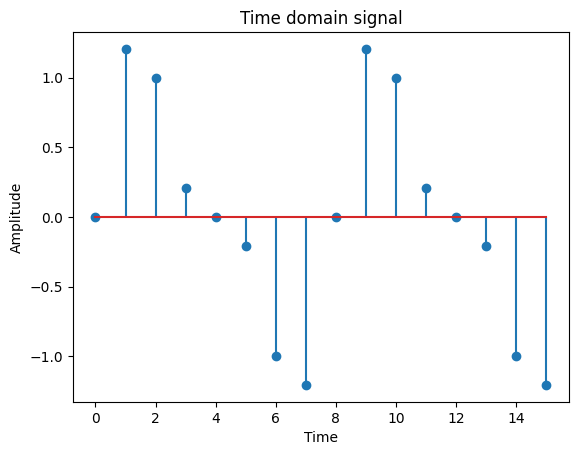

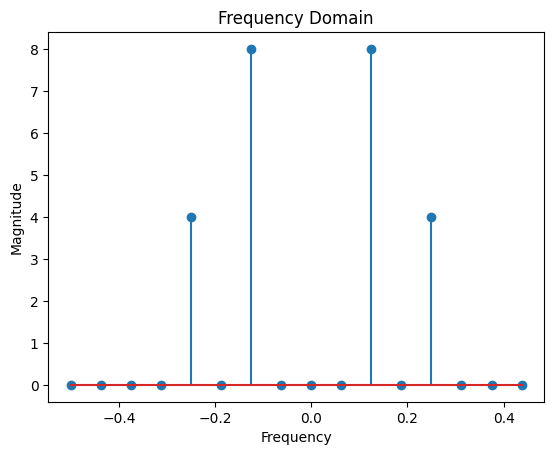

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
N = 16
t = np.arange(N)
signal = np.sin(2*np.pi*2*t/N) + 0.5*np.sin(2*np.pi*4*t/N)
X = np.fft.fft(signal)
freq = np.fft.fftfreq(N)
magnitude = np.abs(X)
plt.figure()
plt.stem(t,signal)
plt.title('Time domain signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()
plt.figure()
plt.stem(freq,magnitude)
plt.title('Frequency Domain')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()